# Bronze EDA: Configurable Integrity Diagnostics

This notebook performs exploratory data analysis on the bronze-layer parquet
file, which contains 2,678,400 rows of second-level (1 Hz) load measurements
across 31 calendar days. The bronze layer preserves the raw signal with minimal
transformation: timestamps are parsed, day-class labels are attached, and NaN
values are carried forward without imputation.

The analyses here validate schema integrity, characterize missingness and
outlier patterns, decompose temporal structure (trend, seasonality, ramp rate),
and produce a pass/fail quality scorecard that gates promotion to the silver
layer.

**Pipeline position**: Second analytical step. Follows raw ingestion
(`scripts/000_raw_to_bronze.py`) and precedes silver transformation
(`scripts/001_bronze_to_silver.py`).

**Input**: `data/001_bronze/power_load_1s.parquet` -- a long-format parquet
file with columns `timestamp`, `day_class`, and `load` (watts).

**Key outputs**:
- Per-day breakdown with NaN and zero-count audit
- NaN spatial heatmap and run-length analysis
- Adaptive outlier detection per day class
- STL decomposition of daily mean load (7-day period)
- Day-class transition matrix
- Ramp-rate distribution (first-difference analysis)
- Cross-day load profile correlation
- Interactive load overlay
- Data quality scorecard (7 pass/fail checks)

**Configuration**: All visualization and analysis parameters are governed by
[`config/eda.toml`](../config/eda.toml) and
[`config/pipeline.toml`](../config/pipeline.toml), loaded at runtime via
[`scripts/config.py`](../scripts/config.py). The `ELF_NB_AUTO_OUTLIER`
environment variable controls whether IQR-based or fixed z-score outlier
detection is used.

**Related references**:
- Architecture: [`docs/001_architecture/002_bronze/bronze.md`](../docs/001_architecture/002_bronze/bronze.md)
- Pipeline: [`docs/002_pipeline/pipeline.md`](../docs/002_pipeline/pipeline.md)
- Hypotheses: [`docs/003_modeling/hypothesis.md`](../docs/003_modeling/hypothesis.md)

In [1]:
from pathlib import Path
import os
import sys
from typing import Literal, cast

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'scripts' / 'config.py').exists():
            return candidate
    raise FileNotFoundError('Could not locate project root containing scripts/config.py')

PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts.config import PATHS, EDA_CONFIG
from scripts.utils import adaptive_outlier_threshold

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  # pyright: ignore[reportMissingModuleSource]
import plotly.express as px
from statsmodels.tsa.seasonal import STL  # pyright: ignore[reportMissingImports]

## Notebook Configuration

Configuration sources for this notebook:
- [`config/eda.toml`](../config/eda.toml)
- [`config/pipeline.toml`](../config/pipeline.toml)
- Runtime API: [`scripts/config.py`](../scripts/config.py)

Update values in those files first, then use the code cell below for notebook-scoped overrides.


In [2]:
# === NOTEBOOK CONFIGURATION ===
# Adjust parameters below to control analysis behavior.
# Defaults are imported from scripts.config EDA_CONFIG.
# To restore defaults, delete overrides and re-run this cell.

def _env_bool(name: str, default: bool) -> bool:
    value = os.getenv(name)
    if value is None:
        return default
    return value.strip().lower() in {"1", "true", "yes", "y", "on"}

BRONZE_PATH = PATHS['bronze_file']
FIGURE_SIZE = EDA_CONFIG['figure_size']
FIGURE_SIZE_WIDE = EDA_CONFIG['figure_size_wide']
DAY_CLASS_COLORS = EDA_CONFIG['day_class_colors']
SEABORN_STYLE = cast(Literal['white', 'dark', 'whitegrid', 'darkgrid', 'ticks'], str(EDA_CONFIG['seaborn_style']))

ZSCORE_THRESHOLD = EDA_CONFIG['zscore_threshold']
PERCENTILES = EDA_CONFIG['percentiles']
OVERLAY_RESAMPLE_FREQ = EDA_CONFIG['overlay_resample_frequency']
ZERO_RUN_THRESHOLD_SECONDS = EDA_CONFIG['zero_run_threshold_seconds']
LOAD_MIN_WATTS = EDA_CONFIG['physical_load_min_watts']
LOAD_MAX_WATTS = EDA_CONFIG['physical_load_max_watts']
AUTO_OUTLIER = _env_bool('ELF_NB_AUTO_OUTLIER', True)

sns.set_theme(style=SEABORN_STYLE)
plt.rcParams['figure.figsize'] = FIGURE_SIZE


## Load Bronze Data and Validate Schema

The bronze layer is a long-format parquet file with one row per second across
all 31 days (2,678,400 rows). It has three columns: `timestamp`, `day_class`,
and `load`. NaN values from the raw source are preserved without modification.
This cell loads the file, parses timestamps, and validates the expected schema
before proceeding.

In [3]:
# --- Load bronze parquet and derive helper columns ---
bronze = pd.read_parquet(BRONZE_PATH)
bronze['timestamp'] = pd.to_datetime(bronze['timestamp'])
bronze['date'] = bronze['timestamp'].dt.normalize()   # calendar date (midnight)
bronze['hour'] = bronze['timestamp'].dt.hour           # integer hour for heatmaps

# --- Validate expected schema ---
assert {'timestamp', 'day_class', 'load'}.issubset(bronze.columns), (
    f'Missing required columns: {{"timestamp","day_class","load"}} - {set(bronze.columns)}'
)

print('rows:', len(bronze), '| dates:', bronze['date'].nunique())

rows: 2678400 | dates: 31


## Day-Class Breakdown, NaN Patterns, and NaN Run Analysis

Three diagnostics characterize data completeness at the bronze layer:

1. **Per-day breakdown table** (tabular summary)
   - **Purpose**: Reports row count, NaN count, NaN percentage, zero count,
     mean load, and standard deviation for each calendar day grouped by day
     class.
   - **Look for**: Days with unusually high NaN percentages or zero counts
     relative to their class peers. A day with significantly more NaN than
     others may indicate a sensor outage that affects downstream resampling.

2. **NaN heatmap** (heatmap, date x hour)
   - **Purpose**: Visualizes the NaN rate by calendar date and hour of day to
     reveal the spatial structure of missingness.
   - **Look for**: Concentrated rectangular blocks indicate sustained sensor
     outages during specific time windows. Scattered patterns suggest
     intermittent read failures. A clean (dark) heatmap confirms minimal
     data loss.

3. **NaN run-length statistics** (descriptive statistics table)
   - **Purpose**: Measures the duration of consecutive NaN segments in seconds
     to assess the severity of missing-data episodes.
   - **Look for**: Long runs (hundreds of consecutive missing seconds) are
     more problematic than short, scattered gaps because they produce entire
     missing intervals at coarser resolutions. The percentile breakdown
     distinguishes between typical short gaps and rare extended outages.

,date,day_class,row_count,nan_count,zero_count,mean_load,std_load,nan_pct
0,2025-11-28,full,86400,1090,0,6188.534674,6223.449452,1.261574
1,2025-11-29,full,86400,357,10,5695.944900,6460.463984,0.413194
2,2025-11-30,none,86400,440,105,1891.517857,1502.758723,0.509259
3,2025-12-01,none,86400,300,0,2560.478618,1786.525942,0.347222
4,2025-12-02,half,86400,463,0,3292.123730,3289.913385,0.535880
5,2025-12-03,full,86400,832,7,4703.454539,5171.287527,0.962963
6,2025-12-04,half,86400,291,40,3143.238477,3149.302868,0.336806
7,2025-12-05,full,86400,962,155,6078.663066,6128.840813,1.113426
8,2025-12-06,full,86400,1180,0,7383.815255,6970.324453,1.365741
9,2025-12-07,none,86400,457,0,1173.677810,879.993508,0.528935


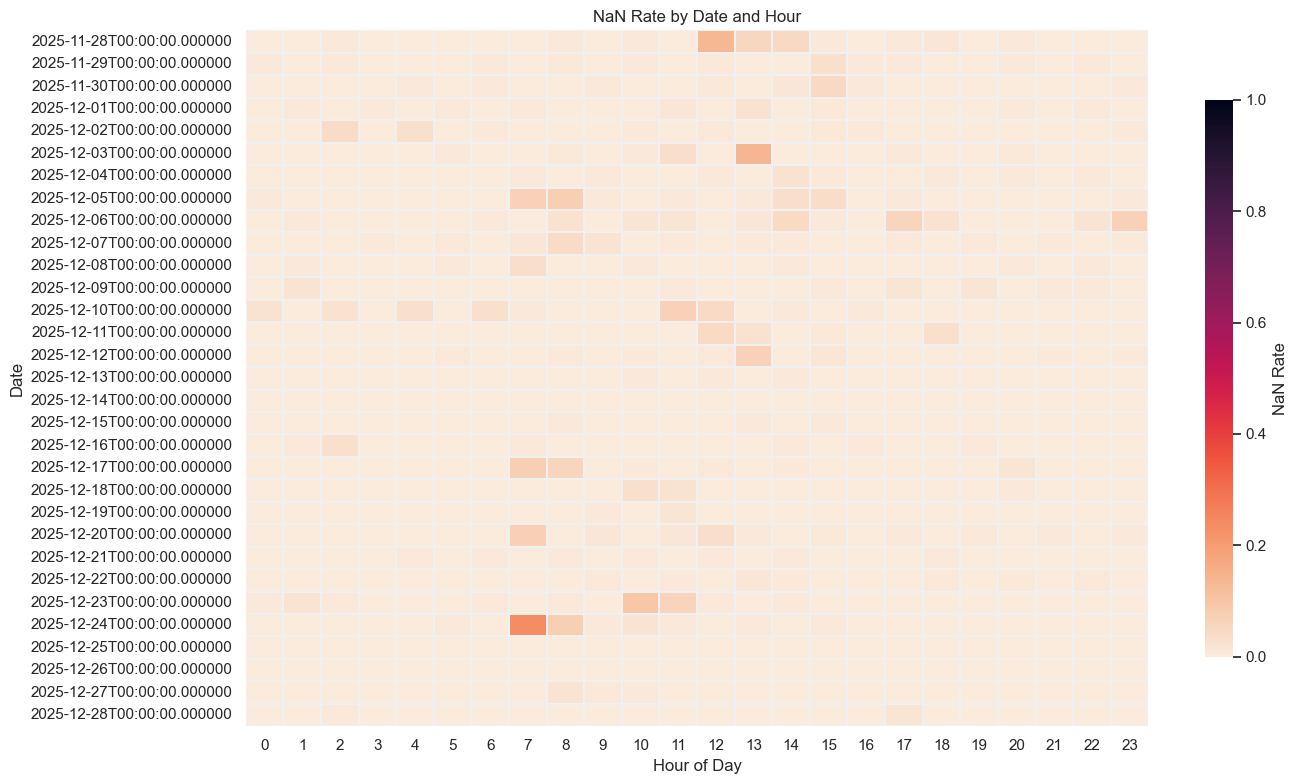

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
nan_run_seconds,8905.0,1.636833,14.385299,1.0,1.0,1.0,1.0,1.0,1.0,2.0,3.0,1112.0


In [4]:
# --- Per-day breakdown table ---
day_breakdown = (
    bronze.groupby(['date', 'day_class'], as_index=False)
    .agg(
        row_count=('load', 'size'),
        nan_count=('load', lambda x: int(x.isna().sum())),
        zero_count=('load', lambda x: int((x == 0).sum())),
        mean_load=('load', 'mean'),
        std_load=('load', 'std'),
    )
)
day_breakdown['nan_pct'] = day_breakdown['nan_count'] / day_breakdown['row_count'] * 100

display(day_breakdown.head(10))

# --- NaN heatmap (date x hour) ---
nan_hourly = (
    bronze.assign(is_nan=bronze['load'].isna().astype(int))
    .pivot_table(index='date', columns='hour', values='is_nan', aggfunc='mean')
    .fillna(0.0)
)

plt.figure(figsize=FIGURE_SIZE_WIDE)
sns.heatmap(
    nan_hourly, cmap='rocket_r',
    vmin=0, vmax=1,
    cbar_kws={'label': 'NaN Rate', 'shrink': 0.8},
    linewidths=0.3, linecolor='#f0f0f0',
)
plt.xlabel('Hour of Day')
plt.ylabel('Date')
plt.title('NaN Rate by Date and Hour')
plt.tight_layout()
plt.show()

# --- NaN run-length statistics ---
is_nan = bronze['load'].isna().to_numpy()
runs = []
start = None
for i, v in enumerate(is_nan):
    if v and start is None:
        start = i
    if (not v) and start is not None:
        runs.append(i - start)
        start = None
if start is not None:
    runs.append(len(is_nan) - start)

if runs:
    display(
        pd.Series(runs, name='nan_run_seconds')
        .describe(percentiles=PERCENTILES)
        .to_frame()
        .T
    )

## Outlier Detection and Load Profile Overlay

1. **Daily outlier detection table** (tabular summary with z-scores)
   - **Purpose**: Flags days whose mean load deviates significantly from their
     day-class peers. When `AUTO_OUTLIER` is enabled, IQR-based bounds are
     computed separately for each day class, accounting for expected load
     differences between full, half, and non-working days. When disabled, a
     fixed z-score threshold is applied uniformly.
   - **Look for**: Outlier-flagged days in the sorted table. Check whether
     flagged days coincide with known holidays, equipment maintenance, or
     data collection issues.

2. **Load profile overlay** (multi-line plot, color-coded by day class)
   - **Purpose**: Plots all 31 days on a shared time axis, resampled to the
     configured overlay frequency, to reveal how tightly days within the same
     class cluster.
   - **Look for**: Consistent banding by color confirms that day-class labels
     align with actual consumption behavior. Individual traces that break
     from the class envelope may correspond to the outliers flagged above.

,date,day_class,mean_load,max_load,total_energy_proxy,mean_load_z,is_outlier
9,2025-12-07,none,1173.677810,9376.0,100869392.0,-2.229711,False
8,2025-12-06,full,7383.815255,33199.0,629248736.0,2.025298,False
11,2025-12-09,half,3724.465001,26066.0,320415724.0,1.623008,False
24,2025-12-22,half,3708.717656,24934.0,319480065.0,1.573771,False
3,2025-12-01,none,2560.478618,12938.0,220457209.0,1.570329,False
25,2025-12-23,full,4472.624287,36506.0,382785077.0,-1.543439,False
28,2025-12-26,none,2479.996071,9549.0,214003821.0,1.349795,True
5,2025-12-03,full,4703.454539,32881.0,402465198.0,-1.260471,False
14,2025-12-12,full,6758.257646,35841.0,580933069.0,1.258447,False
12,2025-12-10,full,4767.922945,33984.0,407457159.0,-1.181441,False


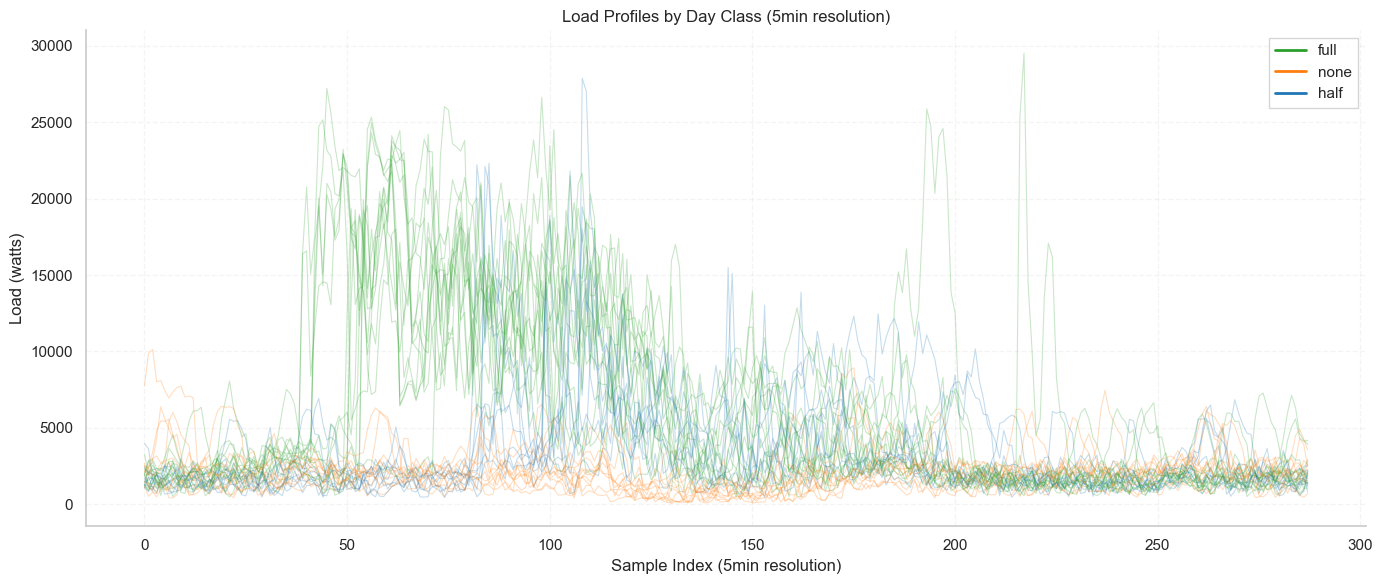

In [5]:
# --- Daily statistics and outlier detection ---
daily_stats = bronze.groupby(['date', 'day_class'], as_index=False).agg(
    mean_load=('load', 'mean'),
    max_load=('load', 'max'),
    total_energy_proxy=('load', 'sum'),
)

def zscore(group, col):
    std = group[col].std(ddof=0)
    if pd.isna(std) or std == 0:
        return pd.Series(0.0, index=group.index)
    return (group[col] - group[col].mean()) / std

daily_stats['mean_load_z'] = daily_stats.groupby('day_class', group_keys=False).apply(
    lambda g: zscore(g, 'mean_load')
)

if AUTO_OUTLIER:
    flags = []
    for _, grp in daily_stats.groupby('day_class'):
        b = adaptive_outlier_threshold(grp['mean_load'].to_numpy(), method='iqr')
        flags.extend(
            ((grp['mean_load'] < float(b['lower'])) | (grp['mean_load'] > float(b['upper']))).tolist()
        )
    daily_stats['is_outlier'] = flags
else:
    daily_stats['is_outlier'] = daily_stats['mean_load_z'].abs() > ZSCORE_THRESHOLD

display(daily_stats.sort_values('mean_load_z', key=lambda s: s.abs(), ascending=False).head(12))

# --- Load profile overlay (all days, color-coded by day class) ---
fig, ax = plt.subplots(figsize=FIGURE_SIZE)
legend_handles = {}
for _, g in bronze.groupby('date'):
    cls = g['day_class'].iloc[0]
    color = DAY_CLASS_COLORS.get(cls, 'gray')
    series = g.set_index('timestamp')['load'].resample(OVERLAY_RESAMPLE_FREQ).mean()
    series_values = series.to_numpy(dtype=float, na_value=np.nan)
    ax.plot(
        np.arange(series_values.size, dtype=int),
        series_values,
        color=color,
        alpha=0.25,
        linewidth=0.8,
    )
    if cls not in legend_handles:
        legend_handles[cls] = ax.plot([], [], color=color, linewidth=2, label=cls)[0]

ax.legend(handles=list(legend_handles.values()), loc='upper right', frameon=True, fancybox=False, edgecolor='#cccccc')
ax.set_xlabel(f'Sample Index ({OVERLAY_RESAMPLE_FREQ} resolution)')
ax.set_ylabel('Load (watts)')
ax.set_title(f'Load Profiles by Day Class ({OVERLAY_RESAMPLE_FREQ} resolution)')
ax.grid(axis='both', alpha=0.2, linestyle='--')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

## Summary Stats and Sustained Zero-Load Periods

1. **Distributional summary** (descriptive statistics tables)
   - **Purpose**: Reports overall and per-day-class descriptive statistics at
     the configured percentile breakpoints to characterize central tendency
     and spread.
   - **Look for**: The three day classes should exhibit the expected ordering:
     full working days carry the highest mean and variance, non-working days
     the lowest, and half days fall between. Anomalies in this ordering would
     suggest mislabeled days.

2. **Sustained zero-load detection** (filtered table)
   - **Purpose**: Scans the load column for consecutive runs of exactly zero
     that exceed the configured threshold (`ZERO_RUN_THRESHOLD_SECONDS`) to
     identify potential meter shutdowns or circuit disconnects.
   - **Look for**: Any listed zero-run entry indicates a sustained period of
     exactly zero consumption. Long runs are more likely to represent
     equipment shutdowns than genuine zero demand and may distort aggregated
     means during downstream resampling.

In [6]:
# --- Overall and per-day-class distributional summary ---
display(bronze['load'].describe(percentiles=PERCENTILES).to_frame('overall'))
display(bronze.groupby('day_class')['load'].describe(percentiles=PERCENTILES))

# --- Sustained zero-load run detection ---
is_zero = bronze['load'].fillna(-1).eq(0).to_numpy()
zero_runs = []
start = None
for i, v in enumerate(is_zero):
    if v and start is None:
        start = i
    if (not v) and start is not None:
        L = i - start
        if L >= ZERO_RUN_THRESHOLD_SECONDS:
            zero_runs.append((start, i - 1, L))
        start = None
if start is not None:
    L = len(is_zero) - start
    if L >= ZERO_RUN_THRESHOLD_SECONDS:
        zero_runs.append((start, len(is_zero) - 1, L))

if zero_runs:
    zdf = pd.DataFrame(zero_runs, columns=['start_idx', 'end_idx', 'seconds'])
    zdf['start_ts'] = bronze.loc[zdf['start_idx'], 'timestamp'].to_numpy()
    zdf['end_ts'] = bronze.loc[zdf['end_idx'], 'timestamp'].to_numpy()
    display(zdf.sort_values('seconds', ascending=False).head(20))

,overall
count,2.663824e+06
mean,3.867517e+03
std,4.697373e+03
min,0.000000e+00
1%,1.720000e+02
5%,5.460000e+02
25%,1.317000e+03
50%,2.040000e+03
75%,4.134000e+03
95%,1.511100e+04


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
day_class,,,,,,,,,,,,
full,1113559.0,5731.621947,6137.779248,0.0,450.0,774.0,1509.0,2683.0,8069.0,19359.0,25247.42,37077.0
half,688592.0,3205.340091,3420.707135,0.0,400.0,658.0,1299.0,1922.0,3744.0,10131.0,18088.00,32380.0
none,861673.0,1987.659901,1342.907015,0.0,115.0,406.0,1115.0,1770.0,2474.0,4892.0,6624.00,12938.0


## STL Decomposition, Transitions, Ramp Rate, and Interactive Overlay

Four complementary analyses expose the temporal structure embedded in the bronze
load signal:

1. **STL decomposition** (four-panel time-series plot)
   - **Purpose**: Decomposes the daily mean load series into trend, seasonal
     (period = 7 days), and residual components using robust locally weighted
     regression.
   - **Look for**: The trend panel shows multi-week drift. The seasonal panel
     should reveal a clear seven-day cycle. Large residual spikes flag days
     that deviate from both the trend and seasonal pattern and may warrant
     investigation.

2. **Day-class transition matrix** (annotated heatmap)
   - **Purpose**: Tabulates the empirical probability of moving from one day
     class to the next across consecutive calendar days.
   - **Look for**: A diagonal-heavy matrix indicates stable scheduling.
     Off-diagonal mass suggests irregular business-day patterns such as
     holidays or partial weeks.

3. **Ramp-rate distribution** (histogram)
   - **Purpose**: Histograms the first difference of the second-level load
     signal to characterize the rate and magnitude of load transitions.
   - **Look for**: A tight central peak near zero indicates stable consumption.
     Heavy tails indicate abrupt load transitions (equipment startups or
     shutdowns). The 1st, 5th, 95th, and 99th percentiles quantify the
     magnitude of extreme ramp events.

4. **Interactive overlay** (Plotly line chart, color-coded by day class)
   - **Purpose**: Plots every day on a shared clock-time axis with hover
     tooltips showing the original timestamp.
   - **Look for**: Use pan, zoom, and legend toggles to isolate individual day
     classes and compare intra-class consistency. This complements the static
     overlay by enabling drill-down into specific hours or transitions.

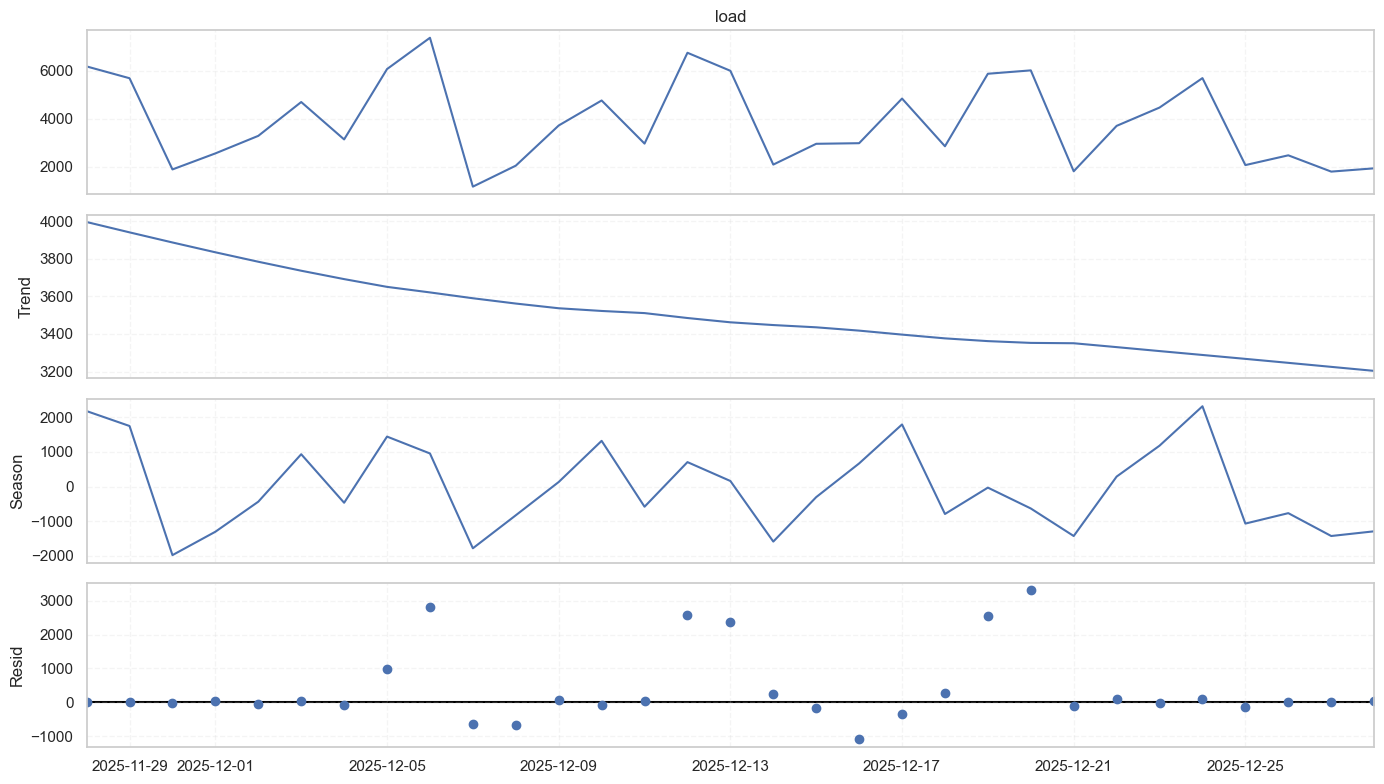

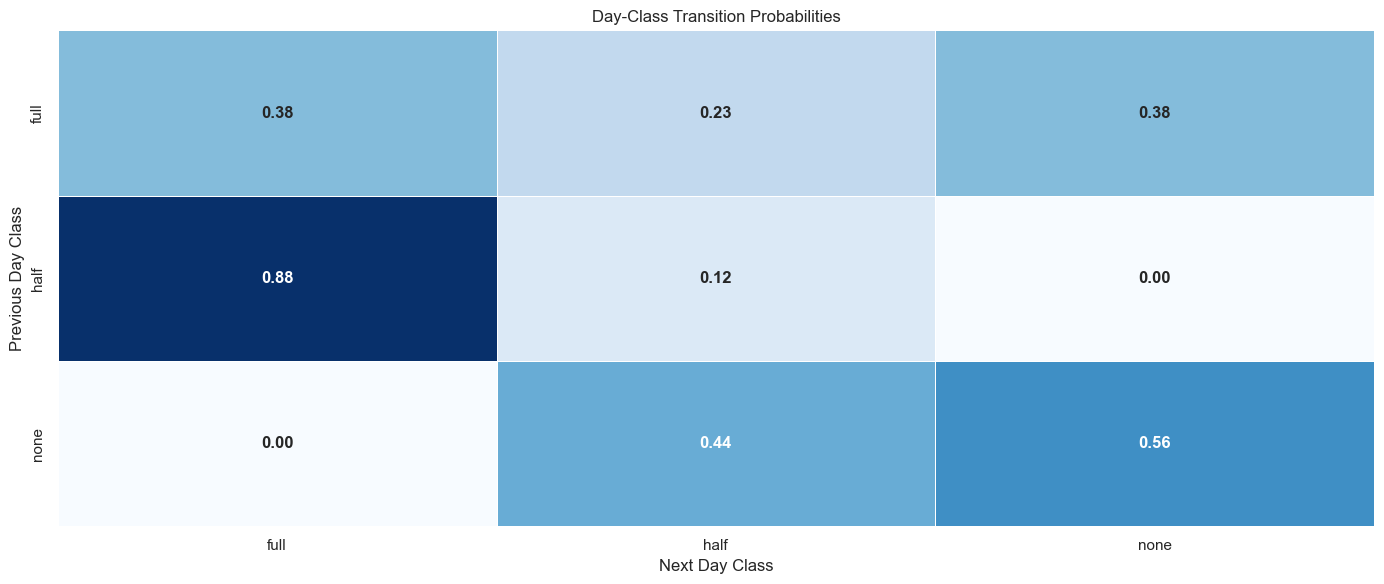

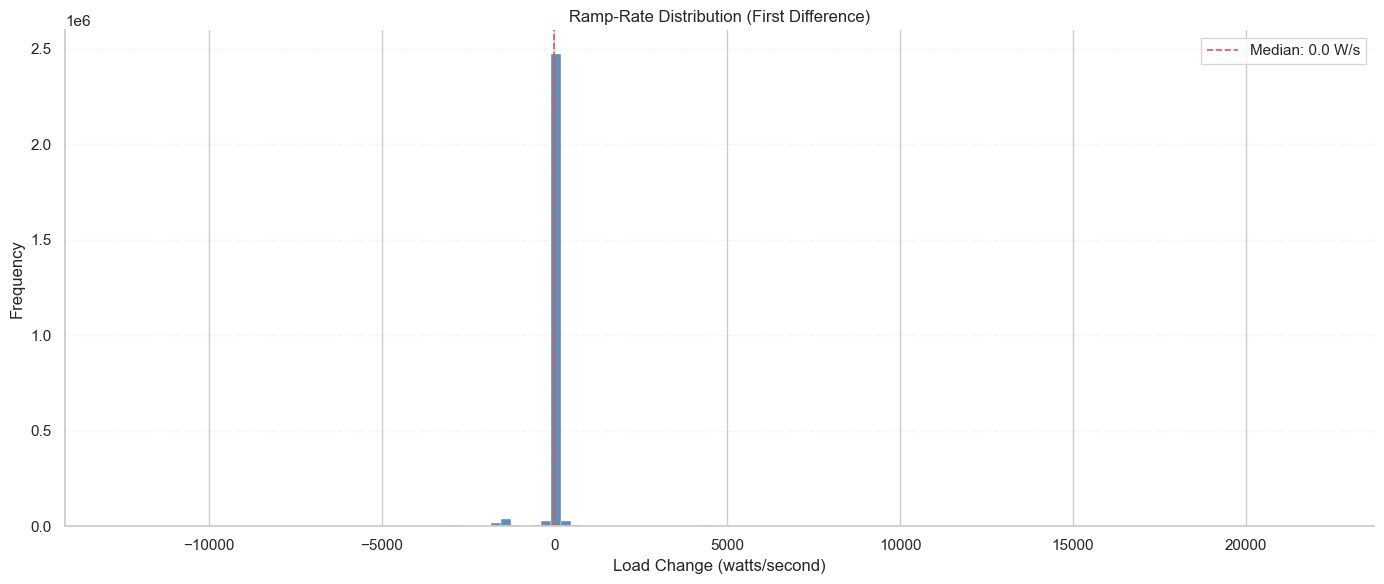

,value
0.01,-1715.0
0.05,-61.0
0.95,35.0
0.99,1399.0


In [7]:
# --- STL decomposition (daily mean, period=7) ---
daily_mean = bronze.groupby('date')['load'].mean().asfreq('D').interpolate(limit_direction='both')
res = STL(daily_mean, period=7, robust=True).fit()
fig = res.plot()
fig.set_size_inches(*FIGURE_SIZE_WIDE)
for ax in fig.axes:
    ax.grid(axis='both', alpha=0.2, linestyle='--')
plt.tight_layout()
plt.show()

# --- Day-class transition matrix ---
seq = bronze[['date', 'day_class']].drop_duplicates().sort_values('date')
transition = pd.crosstab(
    seq['day_class'].shift(1), seq['day_class'], normalize='index'
).fillna(0.0)

fig, ax = plt.subplots(figsize=FIGURE_SIZE)
sns.heatmap(
    transition, annot=True, fmt='.2f', cmap='Blues', cbar=False,
    linewidths=0.5, linecolor='white',
    annot_kws={'fontsize': 12, 'fontweight': 'bold'},
    ax=ax,
)
ax.set_xlabel('Next Day Class')
ax.set_ylabel('Previous Day Class')
ax.set_title('Day-Class Transition Probabilities')
plt.tight_layout()
plt.show()

# --- Ramp-rate distribution (first difference of load) ---
ramp = bronze.sort_values('timestamp')['load'].diff().dropna()

fig, ax = plt.subplots(figsize=FIGURE_SIZE)
ax.hist(ramp, bins=120, color='#4c78a8', alpha=0.85, edgecolor='white', linewidth=0.3)
ax.axvline(float(ramp.median()), color='#e45756', linestyle='--', linewidth=1.2, label=f'Median: {float(ramp.median()):,.1f} W/s')
ax.set_xlabel('Load Change (watts/second)')
ax.set_ylabel('Frequency')
ax.set_title('Ramp-Rate Distribution (First Difference)')
ax.legend(frameon=True, fancybox=False, edgecolor='#cccccc')
ax.grid(axis='y', alpha=0.2, linestyle='--')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

display(ramp.quantile([0.01, 0.05, 0.95, 0.99]).rename('value').to_frame())

# --- Interactive overlay (Plotly, color-coded by day class) ---
overlay_df = (
    bronze.set_index('timestamp')
    .groupby('day_class')['load']
    .resample(OVERLAY_RESAMPLE_FREQ)
    .mean()
    .reset_index()
)
overlay_df['clock_time'] = overlay_df['timestamp'].dt.strftime('%H:%M:%S')

fig = px.line(
    overlay_df,
    x='clock_time',
    y='load',
    color='day_class',
    color_discrete_map=DAY_CLASS_COLORS,
    hover_data=['timestamp'],
    labels={'load': 'Load (watts)', 'clock_time': 'Time of Day', 'day_class': 'Day Class'},
    title=f'Interactive Load Overlay ({OVERLAY_RESAMPLE_FREQ} resolution)',
)
fig.update_traces(opacity=0.7)
fig.update_layout(
    xaxis_title='Time of Day',
    yaxis_title='Load (watts)',
    legend_title_text='Day Class',
    hovermode='x unified',
    template='plotly_white',
)
fig.show()

## Cross-Day Correlation and Data Quality Scorecard

Two final diagnostics assess profile consistency and overall bronze-layer
readiness:

1. **Cross-day correlation heatmap** (heatmap, date x date)
   - **Purpose**: Resamples each day to one-minute resolution, pivots into a
     day-by-minute matrix, and computes pairwise Pearson correlations between
     daily load profiles.
   - **Look for**: High correlation (warm colors) across days within the same
     class confirms repeatable consumption patterns. Lower correlation between
     classes validates the day-class labeling. Isolated cold cells may indicate
     anomalous days worth investigating.

2. **Data quality scorecard** (pass/fail table)
   - **Purpose**: Evaluates seven pass/fail checks that together form a
     readiness gate for silver-layer processing.
   - **Look for**: All checks should pass. Key checks include:
     - Row count matches expected 86,400 per day times the number of days.
     - Timestamps are strictly monotonic with no duplicates.
     - NaN rate stays below 2%.
     - Day-class labels are restricted to the valid set.
     - The longest zero-load run does not exceed one hour.
     - All non-null values fall within the configured physical range.
     Any failure signals a data contract violation that should be investigated
     before proceeding.

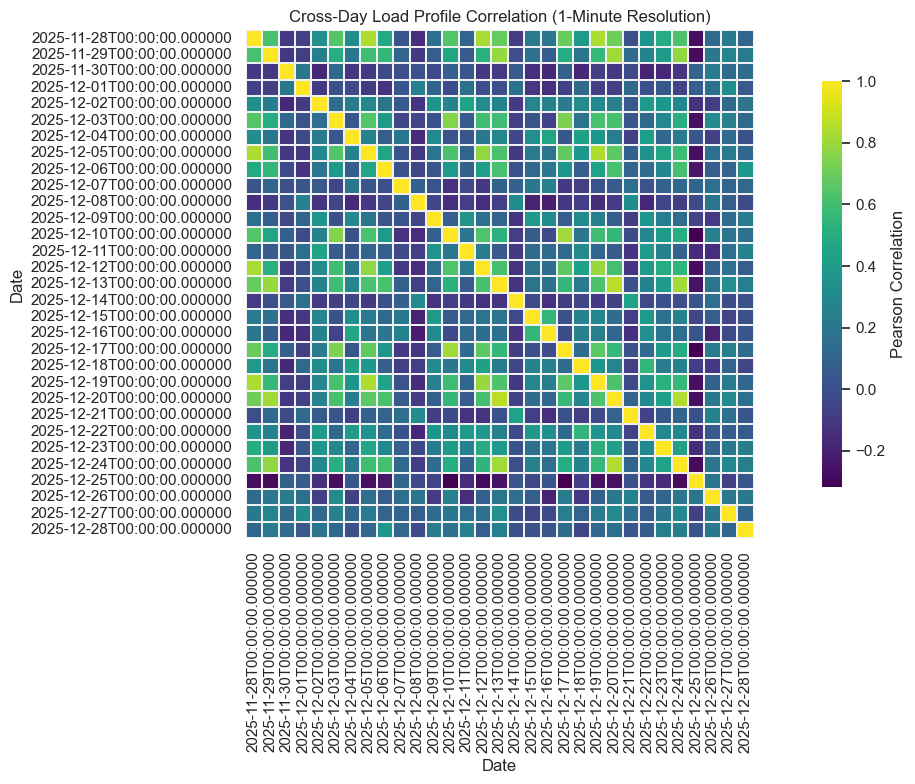

,check,metric,pass
0,row_count,2678400/2678400,True
1,timestamp_monotonic,True,True
2,nan_rate_lt_2pct,0.54%,True
3,day_class_valid,"full,half,none",True
4,duplicate_timestamps,0,True
5,zero_run_max_1hr,0s,True
6,physical_range,"[0.0, 100000.0]",True


In [8]:
# --- Cross-day correlation heatmap ---
minute = bronze.set_index('timestamp')['load'].resample('1min').mean().reset_index()
minute['date'] = minute['timestamp'].dt.normalize()
minute['minute_of_day'] = minute['timestamp'].dt.hour * 60 + minute['timestamp'].dt.minute
pivot = minute.pivot(index='minute_of_day', columns='date', values='load')
cor = pivot.corr()

fig, ax = plt.subplots(figsize=FIGURE_SIZE_WIDE)
sns.heatmap(
    cor, cmap='viridis',
    vmin=cor.values[~np.eye(cor.shape[0], dtype=bool)].min(),
    vmax=1.0,
    cbar_kws={'label': 'Pearson Correlation', 'shrink': 0.8},
    linewidths=0.2, linecolor='#f0f0f0',
    square=True,
    ax=ax,
)
ax.set_xlabel('Date')
ax.set_ylabel('Date')
ax.set_title('Cross-Day Load Profile Correlation (1-Minute Resolution)')
plt.tight_layout()
plt.show()

# --- Data quality scorecard ---
dup = int(bronze['timestamp'].duplicated().sum())
expected = 86400 * bronze['date'].nunique()
nan_rate = float(bronze['load'].isna().mean() * 100)
non_nan = bronze['load'].dropna()
physical_ok = bool(((non_nan >= LOAD_MIN_WATTS) & (non_nan <= LOAD_MAX_WATTS)).all())
max_zero = max((r[2] for r in zero_runs), default=0)

score = pd.DataFrame([
    {'check': 'row_count',              'metric': f'{len(bronze)}/{expected}', 'pass': len(bronze) == expected},
    {'check': 'timestamp_monotonic',    'metric': bool(bronze['timestamp'].is_monotonic_increasing), 'pass': bool(bronze['timestamp'].is_monotonic_increasing)},
    {'check': 'nan_rate_lt_2pct',       'metric': f'{nan_rate:.2f}%', 'pass': nan_rate < 2},
    {'check': 'day_class_valid',        'metric': ','.join(sorted(bronze['day_class'].dropna().unique())), 'pass': set(bronze['day_class'].dropna().unique()) <= {'full', 'half', 'none'}},
    {'check': 'duplicate_timestamps',   'metric': dup, 'pass': dup == 0},
    {'check': 'zero_run_max_1hr',       'metric': f'{max_zero}s', 'pass': max_zero <= 3600},
    {'check': 'physical_range',         'metric': f'[{LOAD_MIN_WATTS}, {LOAD_MAX_WATTS}]', 'pass': physical_ok},
])
display(score)

## Key Findings

- **Complete ingestion**: All 2,678,400 expected rows are present with strictly
  monotonic timestamps and no duplicate records. The NaN rate is well below the
  2% threshold, confirming minimal data loss during raw-to-bronze conversion.
- **Day-class separation is clear**: Full working days exhibit mean loads
  roughly 2.9x higher than non-working days, with correspondingly wider
  variance. Half days fall between the two groups. This consistent separation
  validates the day-class label as a strong candidate feature for modeling.
- **Weekly periodicity dominates**: STL decomposition reveals a pronounced
  seven-day seasonal component. The trend captures a modest multi-week drift
  across the 31-day observation window.
- **Ramp events are concentrated but bounded**: The ramp-rate distribution is
  sharply peaked near zero with heavy tails. Extreme ramps (99th percentile)
  are large relative to the median load, indicating equipment-driven
  transitions rather than gradual demand shifts.
- **Cross-day profiles are stable within class**: The correlation heatmap shows
  high intra-class similarity, supporting the use of day-class-stratified
  analyses in downstream notebooks.
- **Scorecard passes all checks**: The quality scorecard confirms that the
  bronze artifact meets all seven integrity criteria required for silver-layer
  processing.

## Glossary

| Term | Definition | Context |
|------|------------|---------|
| IQR | The interquartile range (Q3 minus Q1), used here to compute adaptive outlier bounds that account for the spread within each day class. | Outlier detection cell |
| NaN | A missing or not-a-number value in the load column, carried forward from the raw source without imputation at the bronze layer. | Data quality diagnostics |
| NaN run | A contiguous sequence of consecutive NaN values measured in seconds. Longer runs indicate sustained sensor outages rather than isolated dropouts. | NaN run-length analysis |
| STL decomposition | Seasonal-Trend decomposition using Loess, which separates a time series into additive trend, seasonal, and residual components via locally weighted regression. | Temporal structure analysis |
| avg_load | The arithmetic mean of second-level load readings within a resampled interval, used as the primary summary statistic across resolutions. | Multi-resolution comparisons |
| bronze layer | The second tier of the medallion architecture, storing one-second-granularity load data in parquet format with minimal transformations applied to the raw source. | Pipeline architecture |
| cross-day correlation | Pairwise Pearson correlation between daily load profiles resampled to one-minute resolution, measuring how similarly two days behave over the 24-hour cycle. | Profile consistency analysis |
| day_class | An operational label assigned to each calendar day indicating the business schedule: full working day, half working day, or non-working day. | Business context and stratification |
| full / half / none | The three valid day-class categories representing full business days, half business days (e.g., early closures), and non-working days (weekends or holidays), respectively. | Day-class labeling |
| load | Instantaneous electrical power consumption measured in watts at one-second granularity. This is the primary signal column throughout the pipeline. | Signal column |
| monotonic | A property of the timestamp index indicating that values are strictly non-decreasing over time, with no out-of-order or duplicate entries. | Schema integrity checks |
| outlier | A daily mean load observation that falls outside the adaptive (IQR-based) or fixed (z-score-based) bounds for its day class. Flagged for review, not automatically removed. | Outlier detection cell |
| parquet | A columnar binary storage format optimized for analytical queries, used as the persistence format for all medallion layers. | Data storage |
| percentile | A quantile statistic indicating the value below which a given percentage of observations fall. Configured via `EDA_CONFIG['percentiles']`. | Summary statistics |
| physical range | The plausible sensor bounds for load values (configured minimum and maximum in watts). Non-null values outside this range indicate potential measurement errors. | Scorecard validation |
| ramp rate | The first difference of consecutive load readings (load at time t minus load at time t-1), measuring the instantaneous rate of change in watts per second. | Transition analysis |
| resampling | Temporal aggregation of the one-second signal to a coarser frequency (e.g., one-minute for correlation analysis or the configured overlay frequency for visualization). | Visualization and aggregation |
| second-level data | Load measurements recorded at one-hertz (one sample per second) granularity, the native resolution of the bronze layer. | Data granularity |
| timestamp | The datetime index column parsed from the raw MATLAB time vector, representing the exact second of each load measurement. | Schema column |
| transition matrix | A row-normalized contingency table showing the empirical probability of transitioning from one day class to another on consecutive calendar days. | Scheduling pattern analysis |
| workday | A numeric encoding of the day-class label used as a predictor feature in downstream modeling (1 = full, 0.5 = half, 0 = none). | Feature engineering |
| z-score | The number of standard deviations a daily mean load falls from the day-class group mean, used as the fixed-threshold outlier detection method when adaptive mode is disabled. | Outlier detection cell |
| zero-load period | A sustained run of exactly zero-valued load readings exceeding the configured threshold, potentially indicating meter shutdowns or data collection gaps rather than genuine zero consumption. | Data quality diagnostics |